In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [2]:
data = pd.read_csv(
    "../data/processed/final_sensor_assisted_dataset.csv"
)

print(data.shape)

data.head()

(11010, 42)


,farmer_id,weather_condition,collection_shift,pH,pH_duplicate,turbidity_ntu,turbidity_log,temperature_c_x,ammonia_content,color_score,...,temp_min,temp_mean,humidity_max,humidity_min,precipitation,wind_speed,storage_risk,tapping_total_hour,weather_stress,vfa
0,0.652174,0.666667,1.0,0.465690,0.465541,0.086036,0.337074,0.377073,0.219000,1.00,...,0.492275,0.507725,0.507725,0.492275,0.492275,0.492275,0.0,0.449019,0.377120,0.073
1,0.673913,0.000000,1.0,0.479828,0.480012,0.069748,0.273708,0.397927,0.234667,0.75,...,0.492275,0.507725,0.507725,0.492275,0.492275,0.492275,0.0,0.449019,0.397972,0.061
2,0.652174,1.000000,1.0,0.532500,0.532451,0.053599,0.190202,0.391341,0.243000,0.50,...,0.492275,0.507725,0.507725,0.492275,0.492275,0.492275,0.0,0.449019,0.391387,0.036
3,0.586957,0.333333,1.0,0.427845,0.428358,0.098205,0.375919,0.392561,0.207333,1.00,...,0.492275,0.507725,0.507725,0.492275,0.492275,0.492275,0.0,0.449019,0.392607,0.094
4,0.369565,1.000000,1.0,0.465862,0.465722,0.082577,0.324852,0.369756,0.223667,1.00,...,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.0,0.027221,0.371999,0.071


In [3]:
X = data.drop(columns=['vfa'])

y = data['vfa']

print(X.shape)
print(y.shape)

(11010, 41)
(11010,)


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(8808, 41)
(2202, 41)


In [5]:
rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    random_state=42
)

rf_model.fit(X_train, y_train)

print("Random Forest trained successfully")

Random Forest trained successfully


In [6]:
y_pred = rf_model.predict(X_test)

In [7]:
mae = mean_absolute_error(y_test, y_pred)

rmse = np.sqrt(
    mean_squared_error(y_test, y_pred)
)

r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 0.0015036976571928197
RMSE: 0.0020467511007941255
R2 Score: 0.992082257133052


In [8]:
importance = rf_model.feature_importances_

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importance
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

feature_importance.head(15)

,Feature,Importance
5,turbidity_ntu,0.702603
6,turbidity_log,0.202314
4,pH_duplicate,0.061837
3,pH,0.029348
8,ammonia_content,0.001940
10,drc,0.000586
9,color_score,0.000302
0,farmer_id,0.000223
7,temperature_c_x,0.000205
40,weather_stress,0.000200


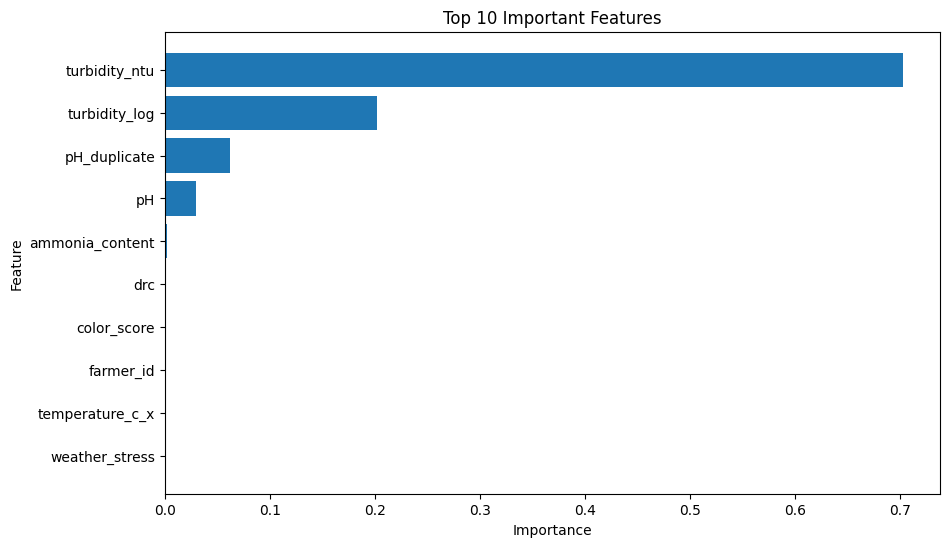

In [9]:
top_features = feature_importance.head(10)

plt.figure(figsize=(10,6))

plt.barh(
    top_features['Feature'],
    top_features['Importance']
)

plt.xlabel("Importance")

plt.ylabel("Feature")

plt.title("Top 10 Important Features")

plt.gca().invert_yaxis()

plt.show()